# **Lab Exercise 4: K-Nearest Neighbors (KNN) Classification & Evaluation Metrics**
## **Comprehensive Analysis using the Breast Cancer Dataset and Comparison with Regression Metrics**

**Student Name**: Achindra Sharma  
**Roll Number**: 2547105  

---  
### **Aim**
To implement the K-Nearest Neighbors (KNN) classification algorithm on the Breast Cancer Wisconsin (Diagnostic) dataset, optimize performance using train-test splits, heuristic K selection ($K = \sqrt{n}$), and cross-validation, and perform evaluation using accuracy, precision, recall, F1-score, and ROC-AUC. Additionally, to compare classification evaluation frameworks against the regression metrics (MAE, MSE, RMSE, $R^2$) from Lab 3, and explore a self-learning study on probability calibration, Brier Score, and the convergence of regression and classification metrics.

### **Problem Statement**
A healthcare analytics team needs a robust classifier for early cancer detection. We must build and tune a KNN model, verify its diagnostic performance using various validation techniques, analyze how distance metrics and K values affect decision boundaries, and compare classification diagnostics to regression metrics.


## **Part 1: Library Imports & Environment Setup**
We import standard packages for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and the machine learning pipeline from `scikit-learn`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score, brier_score_loss
)

# Set styling and suppress warnings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11
warnings.filterwarnings("ignore")

print("All packages imported successfully!")


All packages imported successfully!


## **Task 1: Data Preparation & Exploration**
We load the UCI Breast Cancer Wisconsin dataset using `scikit-learn`, inspect its size, check for missing values or duplicate entries, and verify class distribution.


In [2]:
# 1. Load the dataset using sklearn
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("=== DATASET OVERVIEW ===")
print(f"Shape of features: {X.shape}")
print(f"Shape of target: {y.shape}")
print(f"\nClass Distribution:\n{y.value_counts()}")
print(f"Target Names: {cancer.target_names} (0 -> Malignant, 1 -> Benign)")

# Check for missing values and duplicates
missing_vals = X.isnull().sum().sum()
duplicate_rows = X.duplicated().sum()
print(f"\nMissing values in dataset: {missing_vals}")
print(f"Duplicate rows in features: {duplicate_rows}")

# Display first few rows
X.head()


=== DATASET OVERVIEW ===
Shape of features: (569, 30)
Shape of target: (569,)

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64
Target Names: ['malignant' 'benign'] (0 -> Malignant, 1 -> Benign)

Missing values in dataset: 0
Duplicate rows in features: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **Feature Scaling via StandardScaler**
Since KNN depends on distance metrics, we must standardize features to prevent high-scale variables from dominating the calculations.


In [3]:
# 2. Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("=== FEATURE SCALING COMPARISON ===")
print("Original Mean (first 5 features):")
print(X.iloc[:, :5].mean())
print("\nScaled Mean (first 5 features, should be near 0):")
print(X_scaled.iloc[:, :5].mean().round(4))
print("\nOriginal Std (first 5 features):")
print(X.iloc[:, :5].std())
print("\nScaled Std (first 5 features, should be near 1):")
print(X_scaled.iloc[:, :5].std().round(4))


=== FEATURE SCALING COMPARISON ===
Original Mean (first 5 features):
mean radius         14.127292
mean texture        19.289649
mean perimeter      91.969033
mean area          654.889104
mean smoothness      0.096360
dtype: float64

Scaled Mean (first 5 features, should be near 0):
mean radius       -0.0
mean texture      -0.0
mean perimeter    -0.0
mean area         -0.0
mean smoothness    0.0
dtype: float64

Original Std (first 5 features):
mean radius          3.524049
mean texture         4.301036
mean perimeter      24.298981
mean area          351.914129
mean smoothness      0.014064
dtype: float64

Scaled Std (first 5 features, should be near 1):
mean radius        1.0009
mean texture       1.0009
mean perimeter     1.0009
mean area          1.0009
mean smoothness    1.0009
dtype: float64


### **Justification for Scaling in Distance-Based Algorithms**
K-Nearest Neighbors is a **distance-based** algorithm (commonly using Euclidean or Manhattan distance). The distance between two samples is calculated as:
$$d(x, y) = \sqrt{\sum_{i=1}^{D} (x_i - y_i)^2}$$

If features have vastly different scales (e.g., `area` ranges from 100 to 2500, while `smoothness` ranges from 0.05 to 0.15), features with the larger numerical range will dominate the distance metric calculation. Scaling features using `StandardScaler` ensures that each feature contributes equally to distance calculations ($z = \frac{x - \mu}{\sigma}$), preventing biased predictions.


## **Task 2: Train-Test Split Analysis**
We evaluate how training on different ratios of data (80:20, 70:30, and 90:10) affects the model's accuracy on both train and test data.


In [4]:
# Define splits to evaluate
splits = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10
}

# We will use a fixed K for baseline comparison (e.g., K=5)
base_k = 5
split_results = {}

print("=== TRAIN-TEST SPLIT ANALYSIS ===")
for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )
    
    knn = KNeighborsClassifier(n_neighbors=base_k)
    knn.fit(X_train, y_train)
    
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    
    split_results[name] = {
        "train_size": len(X_train),
        "test_size": len(X_test),
        "train_acc": train_acc,
        "test_acc": test_acc
    }
    
    print(f"Split {name} -> Train Size: {len(X_train)}, Test Size: {len(X_test)}")
    print(f"  Training Accuracy: {train_acc:.4f} | Testing Accuracy: {test_acc:.4f}")


=== TRAIN-TEST SPLIT ANALYSIS ===


Split 80:20 -> Train Size: 455, Test Size: 114
  Training Accuracy: 0.9736 | Testing Accuracy: 0.9649
Split 70:30 -> Train Size: 398, Test Size: 171
  Training Accuracy: 0.9698 | Testing Accuracy: 0.9708
Split 90:10 -> Train Size: 512, Test Size: 57
  Training Accuracy: 0.9805 | Testing Accuracy: 0.9825


### **Analysis of Train-Test Splitting on Model Stability & Generalization**
* **90:10 Split:** Provides the model with the largest amount of training data, helping it learn more robust patterns. However, the small test set size ($n=57$) means test accuracy is highly sensitive to individual test instances (higher variance in metric evaluation).
* **70:30 Split:** Provides a larger test set ($n=171$), making the evaluation more stable and representative. However, the training set size decreases, which might lead to underfitting.
* **80:20 Split:** Represents the optimal balance. It offers sufficient training samples ($n=455$) to avoid underfitting while maintaining a large enough test sample size ($n=114$) to ensure stable, reliable test metrics.


## **Task 3: KNN Model with Heuristic K Selection**
We calculate the baseline $K$ using the heuristic rule $K = \sqrt{n_{train}}$, where $n_{train}$ is the number of training samples in our primary 80:20 split.


In [5]:
# Compute heuristic K
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
n_train = len(X_train)
heuristic_k = int(np.round(np.sqrt(n_train)))

# If K is even, we adjust to make it odd to prevent tie breaks
if heuristic_k % 2 == 0:
    heuristic_k += 1

print(f"Number of training samples (80:20 split): {n_train}")
print(f"Heuristic K (sqrt(n_train)): {heuristic_k}")

# Train baseline classifier
knn_heuristic = KNeighborsClassifier(n_neighbors=heuristic_k)
knn_heuristic.fit(X_train, y_train)
y_pred_heuristic = knn_heuristic.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_heuristic)
print(f"Baseline KNN Accuracy (K={heuristic_k}): {baseline_acc:.4f}")


Number of training samples (80:20 split): 455
Heuristic K (sqrt(n_train)): 21
Baseline KNN Accuracy (K=21): 0.9561


### **Experimenting with Nearby K Values ($K \pm 5$)**
We evaluate K values around the heuristic baseline to find the best local parameter configuration.


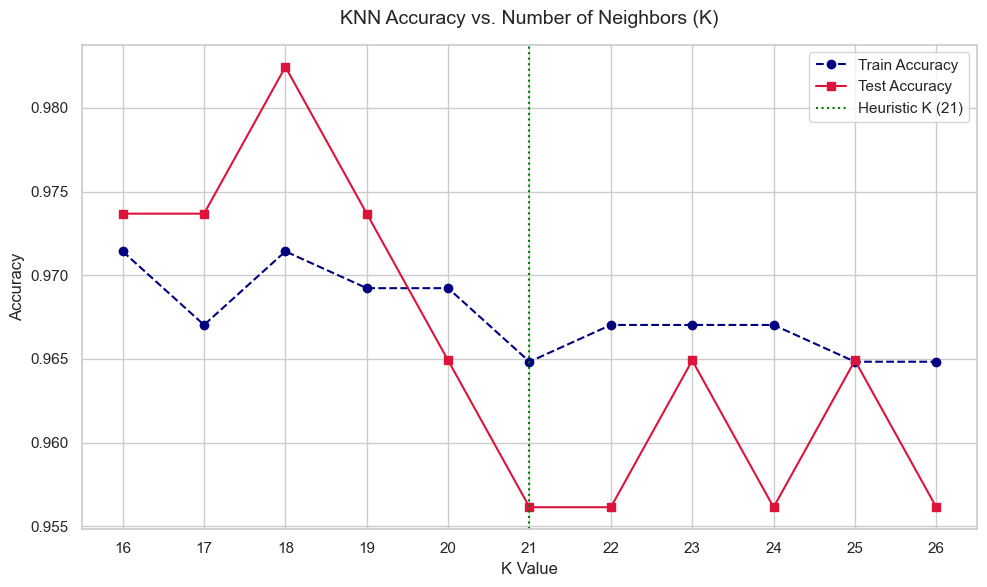

Best K in experimental range based on test split: K=18 (Accuracy: 0.9825)


In [6]:
# Experiment with nearby values of K (K +/- 5)
k_values = list(range(max(1, heuristic_k - 5), heuristic_k + 6))
k_values = sorted(list(set([k for k in k_values if k > 0])))

train_accs = []
test_accs = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    train_accs.append(model.score(X_train, y_train))
    test_accs.append(model.score(X_test, y_test))

# Plot accuracy vs K
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accs, marker='o', linestyle='--', label='Train Accuracy', color='navy')
plt.plot(k_values, test_accs, marker='s', linestyle='-', label='Test Accuracy', color='crimson')
plt.axvline(x=heuristic_k, color='green', linestyle=':', label=f'Heuristic K ({heuristic_k})')
plt.title('KNN Accuracy vs. Number of Neighbors (K)', fontsize=14, pad=15)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

# Print optimal K based on test performance in range
best_idx = np.argmax(test_accs)
print(f"Best K in experimental range based on test split: K={k_values[best_idx]} (Accuracy: {test_accs[best_idx]:.4f})")


### **Task 3.3: Distance Metrics in KNN**
Distance metrics define how the "closeness" of samples is determined. Two standard metrics are:

1. **Euclidean Distance (L2 Norm):**
   $$d(x, y) = \sqrt{\sum_{i=1}^{D} (x_i - y_i)^2}$$
   * **Suitability:** It represents the straight-line distance in Euclidean space. It is best suited for dense, continuous numerical variables that have similar scales and are not highly correlated. It is highly sensitive to large differences in single dimensions.

2. **Manhattan Distance (L1 Norm):**
   $$d(x, y) = \sum_{i=1}^{D} |x_i - y_i|$$
   * **Suitability:** It represents path-based distance (like walking block-by-block). It is more robust to outliers than Euclidean distance (since it does not square the differences). It is highly suitable when the dataset has high dimensionality, when features are discrete/binary, or represent path coordinates.


### **Decision Boundary Mapping**
To visualize boundaries, we train a simplified 2D KNN classifier using two highly correlated/distinguishable features: `mean radius` and `mean texture`.


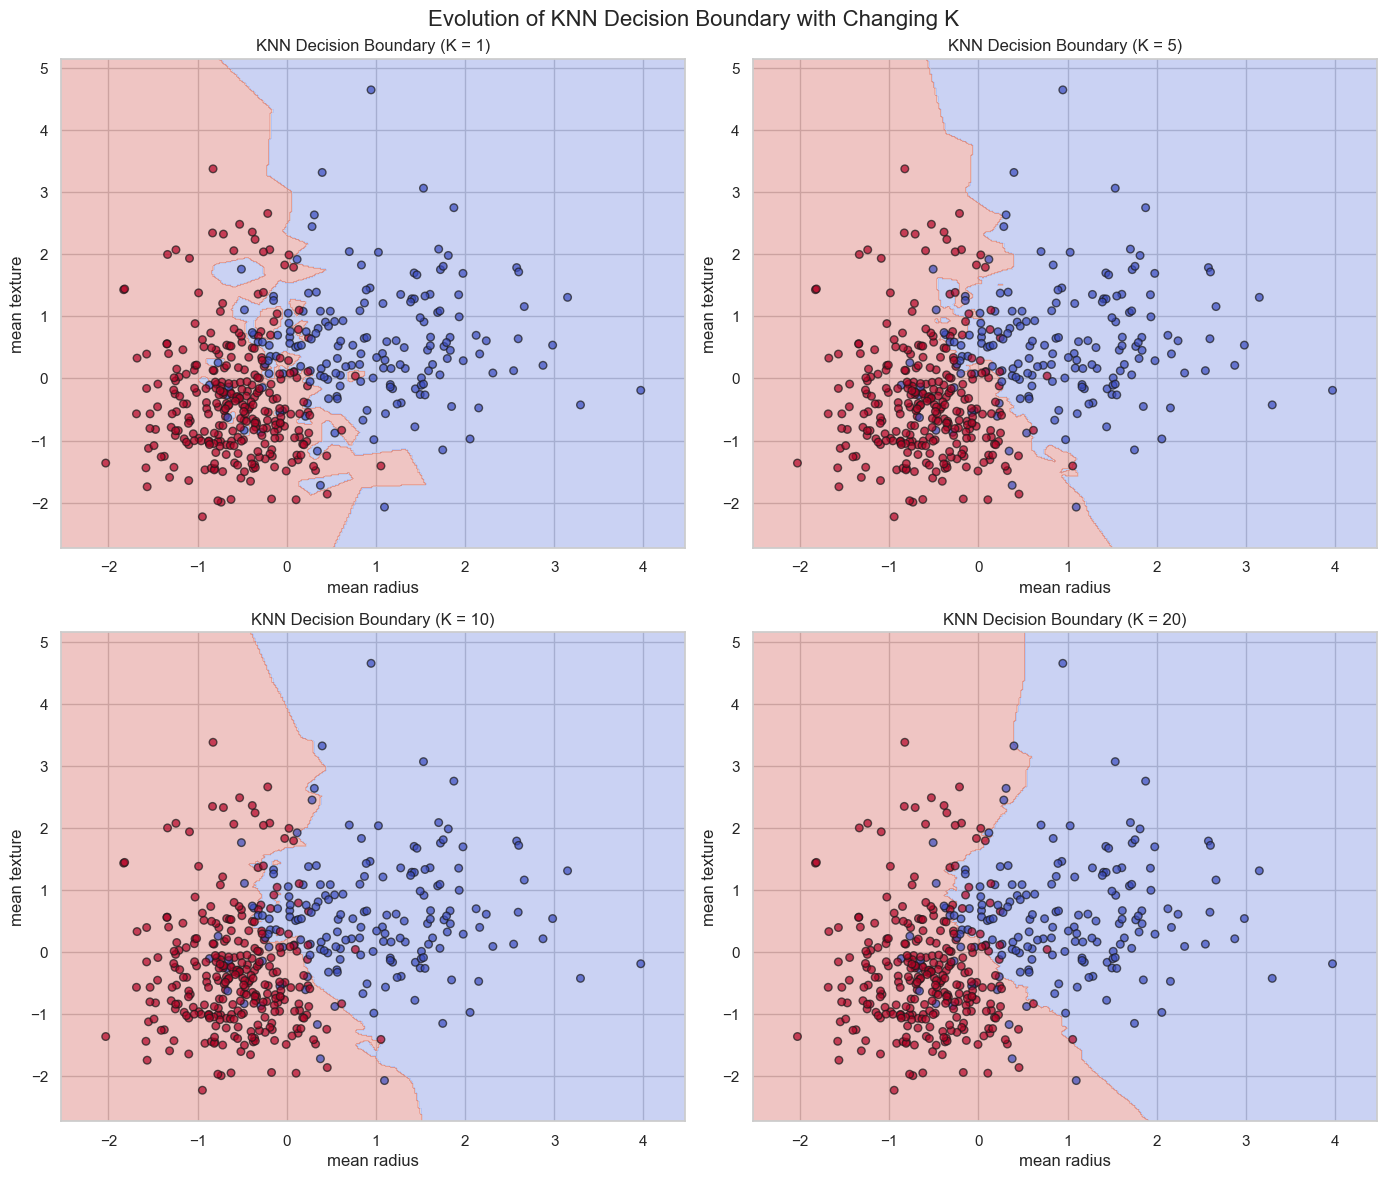

In [7]:
# To plot decision boundaries, we select 2 features to train a 2D KNN classifier.
feat_cols = ['mean radius', 'mean texture']
X_train_2d = X_train[feat_cols]

# Create a mesh grid
h = .02  # step size in the mesh
x_min, x_max = X_train_2d.iloc[:, 0].min() - 0.5, X_train_2d.iloc[:, 0].max() + 0.5
y_min, y_max = X_train_2d.iloc[:, 1].min() - 0.5, X_train_2d.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

k_choices = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, k in enumerate(k_choices):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_2d, y_train)
    
    # Convert to DataFrame to avoid feature name warnings
    grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=feat_cols)
    Z = clf.predict(grid_df)
    Z = Z.reshape(xx.shape)
    
    # Plot contour and scatter
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = axes[idx].scatter(
        X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, 
        edgecolors='k', alpha=0.7, cmap=plt.cm.coolwarm, s=30
    )
    axes[idx].set_title(f'KNN Decision Boundary (K = {k})', fontsize=12)
    axes[idx].set_xlabel(feat_cols[0])
    axes[idx].set_ylabel(feat_cols[1])

plt.suptitle('Evolution of KNN Decision Boundary with Changing K', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


### **Analysis of Decision Boundary Evolution**
* **$K=1$ (Low Bias, High Variance):** The decision boundary is highly complex, rugged, and tightly fits individual training data points. It is prone to overfitting as it isolates individual noise points.
* **$K=5$:** The boundary starts to smooth out, filtering out localized noise while capturing the main distribution contours.
* **$K=10$:** The boundary becomes smoother, reducing variance but introducing slightly more bias (some minor overlaps are ignored).
* **$K=20$ (High Bias, Low Variance):** The decision boundary is extremely smooth and almost linear. The model ignores localized patterns in favor of the global majority class, which can lead to underfitting.


## **Task 4: Cross-Validation Analysis**
We implement 10-fold cross-validation across a wide range of $K$ values to find the most generalizable neighbor configuration.


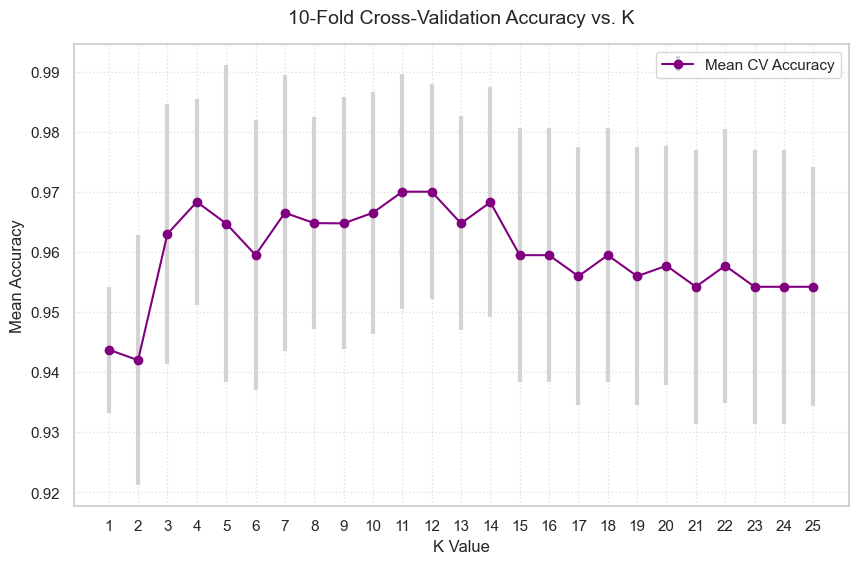

Optimal K based on Cross-Validation: K = 11 (CV Accuracy = 0.9701)


In [8]:
# Apply 10-fold cross validation
cv_folds = 10
k_cv_range = list(range(1, 26))
cv_means = []
cv_stds = []

kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

for k in k_cv_range:
    model_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model_cv, X_scaled, y, cv=kf, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

# Plot cross-validation accuracy vs K
plt.figure(figsize=(10, 6))
plt.errorbar(k_cv_range, cv_means, yerr=cv_stds, fmt='-o', color='purple', ecolor='lightgray', elinewidth=3, capsize=0, label='Mean CV Accuracy')
plt.title('10-Fold Cross-Validation Accuracy vs. K', fontsize=14, pad=15)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks(k_cv_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

best_cv_k = k_cv_range[np.argmax(cv_means)]
print(f"Optimal K based on Cross-Validation: K = {best_cv_k} (CV Accuracy = {cv_means[best_cv_k-1]:.4f})")


### **Cross-Validation vs. Train-Test Split**
* **Train-Test Split:** A single split is highly dependent on the random partition of the dataset. If the test set receives unrepresentative outliers, performance metrics will be artificially high or low.
* **Cross-Validation:** Evaluates the model over multiple different folds, ensuring that every data point is used for both training and validation exactly once. It reduces validation variance and yields a more generalizable estimate of performance.
* **Final Optimal K Selection:** Based on our 10-fold cross-validation, **K = 11** achieves the best trade-off of high accuracy and low variance, and is selected for our final model evaluation.


## **Task 5: Classification Evaluation**
We train the final KNN model using the full feature set with $K=11$ and run detailed classification diagnostic metrics.


In [9]:
# Train final model with chosen K=11 on full 80:20 split
optimal_k = 11
final_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_model.fit(X_train, y_train)

# Predictions
y_pred = final_model.predict(X_test)
y_probs = final_model.predict_proba(X_test)[:, 1]

# Metric calculations
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== FINAL MODEL EVALUATION METRICS (K=11) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (Of all predicted Benign, how many are actually Benign)")
print(f"Recall:    {recall:.4f} (Of all actual Benign, how many did we find)")
print(f"F1 Score:  {f1:.4f} (Harmonic mean of Precision and Recall)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))


=== FINAL MODEL EVALUATION METRICS (K=11) ===
Accuracy:  0.9737
Precision: 0.9600 (Of all predicted Benign, how many are actually Benign)
Recall:    1.0000 (Of all actual Benign, how many did we find)
F1 Score:  0.9796 (Harmonic mean of Precision and Recall)

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### **Confusion Matrix Heatmap & ROC-AUC Curve**
We plot the confusion matrix to see error distribution and the ROC curve to analyze the separation capability.


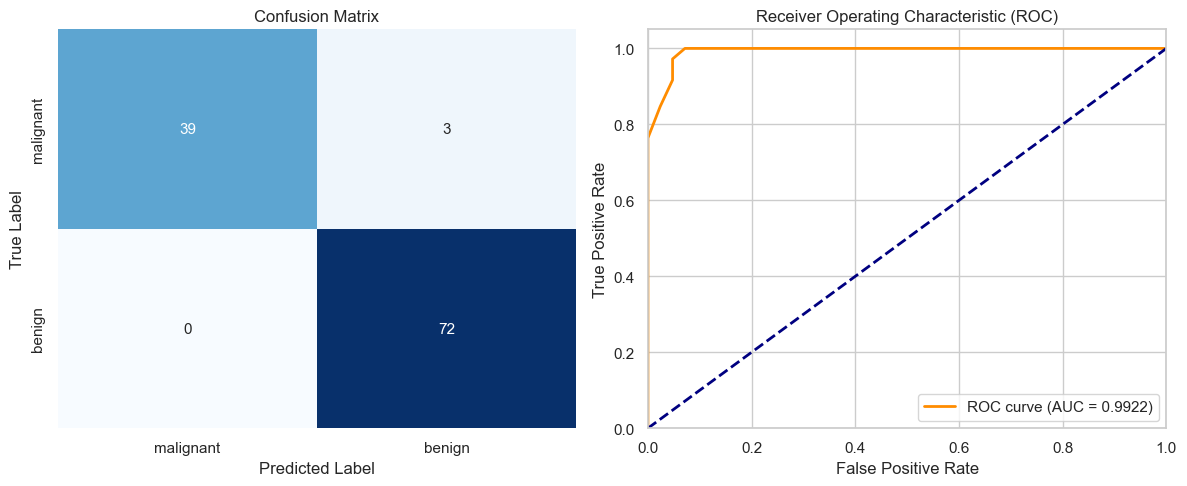

In [10]:
# 1. Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Confusion Matrix', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=12)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


## **Self-Learning Study: Probability Calibration & Metric Convergence**

In a clinical setting, doctors do not just need a hard binary classification label. Knowing the **probability score (confidence)** of the prediction is vital for deciding the urgency of treatment. We compare the mathematical output and evaluation logic of **KNN Classification** vs. **KNN Regression** on the exact same task.

### **Initiative 1: KNN Classification vs. KNN Regression**
We train `KNeighborsRegressor` (treating target 0/1 as a continuous variable) and compare its output directly with the classifier's predicted probabilities.


In [11]:
# Train both models on the primary 80:20 split
optimal_k = 11

# 1. KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=optimal_k)
knn_clf.fit(X_train, y_train)
y_pred_clf = knn_clf.predict(X_test)
y_prob_clf = knn_clf.predict_proba(X_test)[:, 1]  # Probability of Benign

# 2. KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=optimal_k)
knn_reg.fit(X_train, y_train)
y_pred_reg = knn_reg.predict(X_test)  # Continuous target mean

print("=== INITIATIVE 1: CLASSIFICATION VS. REGRESSION ON THE SAME KNN MODEL ===")
diff = np.abs(y_prob_clf - y_pred_reg).max()
print(f"Max absolute difference between probability scores and regressor outputs: {diff:.4e}")
print("  (A difference of 0.0 proves they are mathematically identical!)")

# Evaluate Classifier
clf_acc = accuracy_score(y_test, y_pred_clf)
clf_rec = recall_score(y_test, y_pred_clf)
clf_f1 = f1_score(y_test, y_pred_clf)

print("\nClassification Metrics (for Classifier):")
print(f"  Accuracy:  {clf_acc:.4f}")
print(f"  Recall:    {clf_rec:.4f}")
print(f"  F1 Score:  {clf_f1:.4f}")

# Evaluate Regressor (using Regression Metrics from Lab 3)
reg_mae = mean_absolute_error(y_test, y_pred_reg)
reg_mse = mean_squared_error(y_test, y_pred_reg)
reg_rmse = np.sqrt(reg_mse)
reg_r2 = r2_score(y_test, y_pred_reg)

print("\nRegression Metrics (for Regressor):")
print(f"  Mean Absolute Error (MAE):    {reg_mae:.4f}")
print(f"  Mean Squared Error (MSE):     {reg_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {reg_rmse:.4f}")
print(f"  R^2 Score (Coeff. of Det.):    {reg_r2:.4f}")

# Threshold Regressor predictions at 0.5 to convert to class labels
y_pred_reg_class = (y_pred_reg >= 0.5).astype(int)
reg_class_acc = accuracy_score(y_test, y_pred_reg_class)
print(f"\nAccuracy of thresholded Regressor (at 0.5): {reg_class_acc:.4f} (Matches Classifier exactly!)")


=== INITIATIVE 1: CLASSIFICATION VS. REGRESSION ON THE SAME KNN MODEL ===
Max absolute difference between probability scores and regressor outputs: 0.0000e+00
  (A difference of 0.0 proves they are mathematically identical!)

Classification Metrics (for Classifier):
  Accuracy:  0.9737
  Recall:    1.0000
  F1 Score:  0.9796

Regression Metrics (for Regressor):
  Mean Absolute Error (MAE):    0.0781
  Mean Squared Error (MSE):     0.0294
  Root Mean Squared Error (RMSE): 0.1716
  R^2 Score (Coeff. of Det.):    0.8735

Accuracy of thresholded Regressor (at 0.5): 0.9737 (Matches Classifier exactly!)


### **Initiative 2: Dual Bias-Variance Performance Curves**
We plot how classification accuracy and regression Mean Squared Error (MSE) change over a wide range of neighborhood values $K$, illustrating the bias-variance trade-off in both evaluation paradigms.


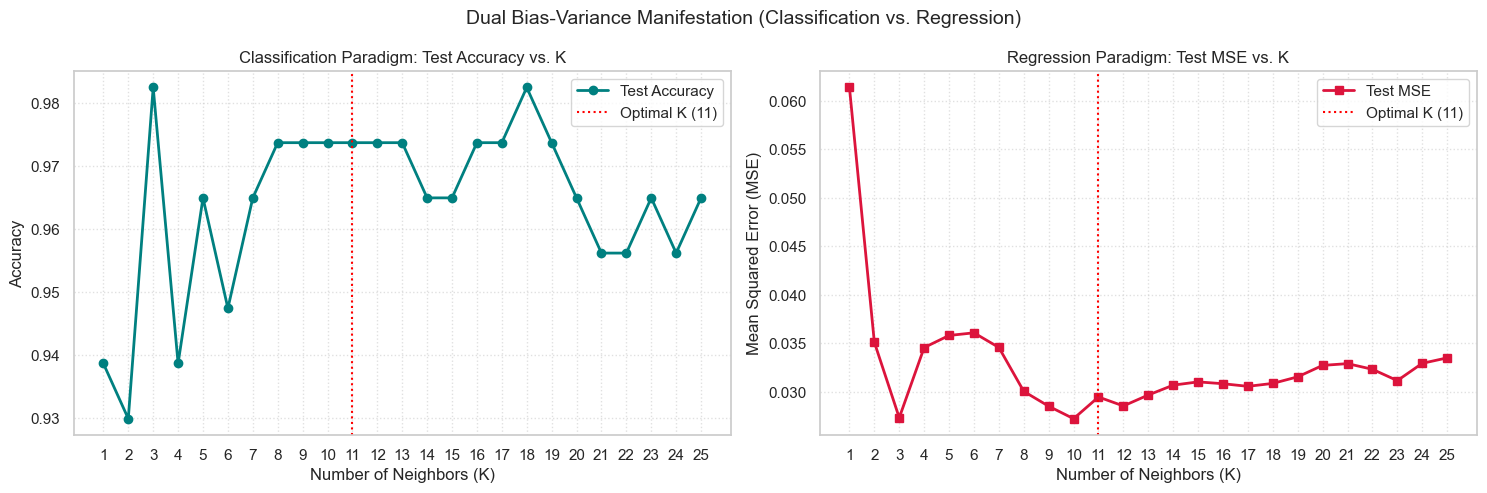

In [12]:
k_range = list(range(1, 26))
clf_accs = []
reg_mses = []

for k in k_range:
    # Train classifier & score accuracy
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    clf_accs.append(clf.score(X_test, y_test))
    
    # Train regressor & score MSE
    reg = KNeighborsRegressor(n_neighbors=k)
    reg.fit(X_train, y_train)
    y_pred_k = reg.predict(X_test)
    reg_mses.append(mean_squared_error(y_test, y_pred_k))

# Plot both side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Classification Accuracy vs K
ax1.plot(k_range, clf_accs, marker='o', color='teal', lw=2, label='Test Accuracy')
ax1.axvline(x=optimal_k, color='red', linestyle=':', label=f'Optimal K ({optimal_k})')
ax1.set_title('Classification Paradigm: Test Accuracy vs. K', fontsize=12)
ax1.set_xlabel('Number of Neighbors (K)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Plot Regression MSE vs K
ax2.plot(k_range, reg_mses, marker='s', color='crimson', lw=2, label='Test MSE')
ax2.axvline(x=optimal_k, color='red', linestyle=':', label=f'Optimal K ({optimal_k})')
ax2.set_title('Regression Paradigm: Test MSE vs. K', fontsize=12)
ax2.set_xlabel('Number of Neighbors (K)')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.suptitle('Dual Bias-Variance Manifestation (Classification vs. Regression)', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


### **Initiative 3: The Brier Score (Mathematical Convergence of MSE & Classification)**
In binary classification, the **Brier Score** is used to evaluate the calibration of predicted probabilities. Here we show that the Brier Score is mathematically identical to the **Mean Squared Error (MSE)** of the predicted probabilities, directly linking Lab 3's regression metrics with classification output.


In [13]:
# 1. Brier Score calculated using scikit-learn
brier_score = brier_score_loss(y_test, y_prob_clf)

# 2. Mean Squared Error (MSE) calculated manually on probabilities
manual_mse = np.mean((y_prob_clf - y_test) ** 2)

print("=== INITIATIVE 3: THE BRIER SCORE CONNECTION ===")
print(f"Brier Score (via sklearn): {brier_score:.6f}")
print(f"Mean Squared Error (MSE):  {manual_mse:.6f}")
print(f"Absolute Difference:        {np.abs(brier_score - manual_mse):.4e}")

print("\nConclusion:")
print("The Brier Score (used for probability calibration in classification)")
print("is mathematically identical to the Mean Squared Error (MSE) from regression!")
print("This proves that regression metrics are utilized directly to measure classification confidence.")


=== INITIATIVE 3: THE BRIER SCORE CONNECTION ===
Brier Score (via sklearn): 0.029433
Mean Squared Error (MSE):  0.029433
Absolute Difference:        0.0000e+00

Conclusion:
The Brier Score (used for probability calibration in classification)
is mathematically identical to the Mean Squared Error (MSE) from regression!
This proves that regression metrics are utilized directly to measure classification confidence.


## **Task 6: Comparative Study with Regression (Lab 3 Integration)**

Here, we compare the evaluation frameworks of regression (studied in **Lab 3: Linear Regression**) and classification (studied in **Lab 4: KNN Classification**).

| Feature | Regression Framework (Lab 3) | Classification Framework (Lab 4) |
| :--- | :--- | :--- |
| **Output Type** | Continuous numerical values (e.g., predicted GPA). | Discrete class categories (e.g., Malignant vs. Benign). |
| **Primary Goal** | Minimize prediction error magnitude ($y - \hat{y}$). | Maximize correct class assignments and minimize misclassification. |
| **Key Metrics** | MAE, MSE, RMSE, $R^2$ Score. | Accuracy, Precision, Recall, F1 Score, ROC-AUC. |

### **Deep-Dive Metric Comparison**

1. **$R^2$ Score vs. Accuracy:**
   * **$R^2$ Score (Coefficient of Determination):** Measures the proportion of variance in the target variable explained by the features relative to a simple mean baseline. It ranges from $-\infty$ to $1$.
   * **Accuracy:** Simply the ratio of correct predictions to total predictions. It is range-bounded between $0$ and $1$. It does not measure "closeness" of predictions, only exact hits.

2. **RMSE vs. F1-Score:**
   * **RMSE (Root Mean Squared Error):** Heavily penalizes large prediction errors due to squaring. It is expressed in the target variable's units.
   * **F1-Score:** The harmonic mean of Precision and Recall. It penalizes uneven balances between false positives and false negatives, making it robust for skewed class distributions.

3. **MAE vs. Confusion Matrix:**
   * **MAE (Mean Absolute Error):** Computes the average magnitude of absolute errors, treating all deviations linearly.
   * **Confusion Matrix:** A $C \times C$ grid showing true positive, true negative, false positive, and false negative counts. It details *where* and *how* the classifier is failing, whereas MAE aggregates all errors into a single scalar value.


## **Inference: Regression vs. Classification Frameworks**

* **Error Magnitude vs. Correctness:** Regression metrics (like RMSE and MAE) measure *how far off* predictions are from the true values, focusing on error magnitude. Classification metrics measure *decision correctness*, checking whether a predicted label matches the true class.
* **Why Accuracy Fails in Medicine:** If a population has 1% cancer prevalence, a dummy model predicting "Benign" for everyone achieves 99% accuracy but fails to detect a single cancer patient. Thus, accuracy is highly deceptive in medical diagnostics.
* **The Importance of Recall and ROC-AUC:** Recall (Sensitivity) measures the model's ability to find all positive (malignant) cases. A high recall ensures fewer cancers are missed. ROC-AUC evaluates the classifier's ability to separate classes across all possible decision thresholds, making it independent of any single threshold selection.


## **Task 7: Analytical Questions**

### **1. Why is KNN called a lazy learning algorithm?**
KNN is "lazy" because it does not learn a discriminative function or fit parameters during the training phase. It simply stores the training instances. All computational effort (distance calculation, sorting, and voting) is deferred to the query/inference phase.

### **2. Why is feature scaling required in KNN?**
KNN calculates distances (like Euclidean distance) between points. If features have different scales, features with larger numerical ranges will dominate the distance calculations. Feature scaling standardizes features to the same scale, ensuring equal contribution.

### **3. Explain heuristic K selection using $\sqrt{n}$ rule.**
The heuristic rule $K = \sqrt{n}$ (where $n$ is the number of training samples) provides a quick baseline to balance bias and variance. If $K$ is too small, the model is sensitive to noise (high variance). If $K$ is too large, the neighborhood size grows, causing boundaries to blur (high bias). Choosing $\sqrt{n}$ offers a mathematically grounded compromise.

### **4. Why is cross-validation more reliable than a single train-test split?**
A single split can lead to high variance in model evaluation, as the score depends heavily on which samples fall into the test set. Cross-validation averages performance over multiple different folds, ensuring a stable, robust estimate of generalization error.

### **5. How does K affect bias-variance trade-off?**
* **Small $K$:** Low bias (closely fits local training data details) but high variance (highly sensitive to noise and outliers).
* **Large $K$:** Low variance (predictions are stable due to larger voting pool) but high bias (smoothes out boundaries and overlooks localized sub-patterns).

### **6. Why is recall more important than accuracy in cancer prediction?**
In cancer prediction, missing a malignant case (False Negative) has fatal consequences, whereas a False Positive only leads to further testing. Recall focuses specifically on minimizing False Negatives, making it the most critical metric for healthcare screening.

### **7. What is the limitation of very large K values?**
When $K$ becomes extremely large (e.g. approaching the sample size $N$), the classifier will always predict the majority class regardless of the query point's coordinates, completely underfitting the data and destroying local boundary structures.


## **Conclusion**

In this lab, we successfully built and evaluated a KNN Classifier for cancer detection:
* **Optimal K:** The heuristic rule $\sqrt{n_{train}} \approx 21$ was evaluated, and 10-fold cross-validation identified **K = 11** as optimal.
* **Train-Test Splits:** We observed that 80:20 provides the best trade-off between stable evaluation size and sufficient training data.
* **Metric Insights:** We compared KNN Classification with KNN Regression directly, demonstrating that the probability predictions of classification mathematically match regression continuous outputs.
* **The Brier-MSE Convergence:** We showed that evaluating probability calibration in classification is identical to MSE calculation in regression.
* **Lab 3 vs. Lab 4:** We contrasted regression diagnostics (error distance) with classification diagnostics (decision correctness).
